<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/banner.svg"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# **Workshop: Decodificación de Gliomas con ML e IA Interpretable**
# **Proyecto Endowment I+D: DI-07-25/ICS | UNAB - PUC - FALP**
---

# **1. Preprocesamiento: Escalamiento Estándar (`StandardScaler`)**

En los estudios de radiómica, las características extraídas de las imágenes de Resonancia Magnética (RM) miden propiedades de naturaleza muy distinta. Por ejemplo, mientras que el **volumen** del tumor puede medirse en miles de milímetros cúbicos, la **entropía de la textura** suele ser un valor decimal pequeño entre 0 y 2.

Si introducimos estos datos crudos en algoritmos estadísticos o de reducción de dimensionalidad, las variables con magnitudes numéricas más grandes dominarán por completo el cálculo, ignorando variables sutiles pero potencialmente más informativas.

Para solucionar esto, aplicamos una **Estandarización Z-score**. Este algoritmo transforma cada característica de forma independiente mediante la fórmula:

$$z = \frac{x - \mu}{\sigma}$$

Donde:

* $x$ es el valor original.
* $\mu$ es la media de esa característica en todo el dataset.
* $\sigma$ es la desviación estándar.

**Resultado:** Todas las variables del dataset transformado tendrán una **media de 0 y una desviación estándar de 1**, garantizando que cada característica radiómica compita en igualdad de condiciones en los siguientes pasos del pipeline.

# **2. Selección de Características: Filtro ANOVA (`SelectKBest` con `f_classif`)**

El análisis de radiómica suele generar cientos o miles de características (forma, intensidad, textura de primer, segundo y alto orden). Muchas de ellas son redundantes o puro "ruido" que no ayuda a diferenciar los tipos de tumores. La **Selección de Características (Feature Selection)** busca identificar el subconjunto de variables originales que guardan la mayor relación con la variable objetivo.

En este pipeline utilizamos un enfoque de tipo **Filtro (Filter Method)** mediante la prueba estadística **ANOVA (Análisis de Varianza)** de una vía (`f_classif`):

* **¿Cómo funciona?** El algoritmo evalúa cada característica radiómica por separado. Divide a los pacientes según su grupo biológico (ej. LGG vs HGG) y analiza si los valores de esa característica específica varían significativamente entre un grupo y otro.

* **El Score F:** Calcula la razón entre la varianza entre los grupos y la varianza dentro de los grupos. Un **Score F alto** significa que la característica es muy diferente entre pacientes con LGG y HGG, pero muy similar entre pacientes del mismo grupo.

El componente `SelectKBest` simplemente ordena todas las características de mayor a menor según su Score F y conserva únicamente las $K$ mejores (en nuestro caso, las 10 prioritarias), descartando el resto.

# **3. Reducción de Dimensionalidad y Visualización: t-SNE**


El algoritmo **t-SNE (t-Distributed Stochastic Neighbor Embedding)** es una técnica de aprendizaje no supervisado utilizada principalmente para la **exploración visual de datos de alta dimensionalidad**.

A diferencia de técnicas lineales como PCA (Análisis de Componentes Principales), t-SNE es excelente capturando **relaciones no lineales complejas** y estructuras locales en los datos.

* **Paso 1 (Espacio de Alta Dimensión)**: t-SNE convierte las distancias euclidianas entre los perfiles radiómicos de los pacientes en probabilidades condicionales que representan su similitud. Si dos pacientes tienen texturas tumorales muy parecidas en la RM, su probabilidad de ser "vecinos" es alta.

* **Paso 2 (Espacio de Baja Dimensión)**: El algoritmo crea un nuevo espacio (usualmente un mapa 2D) y define una distribución de probabilidad similar (utilizando una distribución t-Student) para los puntos en este nuevo plano.

* **Paso 3 (Optimización):** Mediante una función matemática llamada **Divergencia de Kullback-Leibler**, t-SNE mueve los puntos en el mapa 2D de forma iterativa hasta que la estructura de vecindad del plano bajo coincida lo mejor posible con la del espacio original de alta dimensión.

**Uso en el pipeline**: t-SNE se utiliza como herramienta de diagnóstico visual. Al comparar el mapa t-SNE antes de la selección contra el mapa generado después de la selección, evaluamos si el filtro estadístico realmente ayudó a que los pacientes de una misma clase se agrupen de forma más compacta y limpia.

# **4. Modelado Predictivo: Regresión Logística**

Una vez que hemos seleccionado las características radiómicas más relevantes, el pipeline implementa un modelo matemático para automatizar el diagnóstico. La **Regresión Logística** es un algoritmo clásico de clasificación supervisada.

A pesar de su nombre, no predice un valor continuo, sino la **probabilidad** de que una observación pertenezca a una categoría específica (en este caso, la probabilidad de que un paciente tenga un glioma de alto grado, HGG).El modelo toma las características seleccionadas ($x_1, x_2, ..., x_n$), les asigna un peso o coeficiente matemático ($w_1, w_2, ..., w_n$) y calcula una combinación lineal. Finalmente, pasa este resultado a través de la **función sigmoide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Esta función comprime cualquier valor numérico de entrada en un rango estrictamente acotado **entre 0 y 1**, lo que nos permite interpretar el resultado directamente como una probabilidad médica. Si la probabilidad es mayor a 0.5 (50%), el pipeline clasifica al paciente como HGG; de lo contrario, se clasifica como LGG.

<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/sigmoide.svg" width="700" height="500" style="object-fit: contain;">

**5. Validación Clínica: Matriz de Confusión y Métricas**
Para evaluar de forma estricta si nuestro pipeline funciona en un entorno clínico simulado, el dataset se divide en dos partes independientes: **Entrenamiento** (70% de los datos, usados para que el modelo aprenda) y **Prueba** (30% de los datos, retenidos para simular nuevos pacientes que llegan a un hospital).

**La Matriz de Confusión** es una tabla de doble entrada que contrasta los diagnósticos reales (la verdad biológica/patológica) frente a las predicciones generadas por el algoritmo en el conjunto de prueba:

* **Verdaderos Positivos (TP):** Pacientes con HGG diagnosticados correctamente como HGG.

* **Verdaderos Negativos (TN):** Pacientes con LGG diagnosticados correctamente como LGG.

* **Falsos Positivos (FP) - Error Tipo I:** Pacientes con LGG que el modelo clasificó erróneamente como HGG.

* **Falsos Negativos (FN) - Error Tipo II:** Pacientes con HGG que el modelo clasificó erróneamente como LGG (este suele ser el error más crítico en oncología médica).

A partir de esta matriz se desprenden las métricas del reporte final:

* **Precision (Precisión)**: De todos los pacientes que el modelo etiquetó como HGG, ¿cuántos lo eran realmente? (Evita falsas alarmas).

* **Recall / Sensitivity (Sensibilidad)**: De todos los pacientes que realmente tenían HGG, ¿cuántos logró detectar el algoritmo? (Evita pasar por alto tumores agresivos).

* **F1-Score**: Es el promedio armónico entre la Precisión y la Sensibilidad, ofreciendo una métrica única y balanceada del éxito del pipeline.

<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/confussion_matrix.svg" width="700" height="500" style="object-fit: contain;">

# **1: Importación de librerías y carga de datos**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Preprocesamiento y Selección
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Herramienta de Reducción de Dimensionalidad (Visualización)
from sklearn.manifold import TSNE

# Configuración de gráficos
sns.set_theme(style="whitegrid")
%matplotlib inline

# 1. Cargar el dataset directamente desde la URL RAW de GitHub
url = "https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Dataset/radiomics_with_classes_cleaned_T1.csv"
df = pd.read_csv(url)

print(f"Dimensiones del dataset original: {df.shape}")
df.head()

Dimensiones del dataset original: (36, 109)


,Subjects,Elongation T1,Flatness T1,Least Axis Length T1,Major Axis Length T1,Maximum 2D Diameter Column T1,Maximum 2D Diameter Row T1,Maximum 2D Diameter Slice T1,Maximum3DDiameter T1,Mesh Volume T1,...,GLSZM Small Area Low Gray Level Emphasis T1,GLSZM Zone Entropy T1,GLSZM Zone Percentage T1,GLSZM Zone Variance T1,NGTDM Busyness T1,NGTDM Coarseness T1,NGTDM Complexity T1,NGTDM Contrast T1,NGTDM Strength T1,Classes
0,Paciente1,0.75839,0.43938,25.0768,57.0734,52.497619,64.280635,69.856997,70.313583,40813.666667,...,0.001357,7.058039,0.477193,17.908347,0.122552,0.001593,11633.442604,0.228737,4.370588,2
1,Paciente4,0.88536,0.59927,55.2262,92.1564,101.921538,103.324731,105.261579,108.314357,276539.000000,...,0.000371,7.278357,0.408585,52.372523,0.619551,0.000256,12045.202428,0.121847,0.927877,3
2,Paciente5,0.83614,0.61774,30.7269,49.7404,52.497619,61.188234,57.723479,61.708994,43343.000000,...,0.000886,7.068903,0.450854,16.402756,0.140375,0.001492,9017.160060,0.195479,3.948558,2
3,Paciente5c,0.65309,0.46716,27.0553,57.9142,41.617304,59.059292,50.000000,61.351447,18268.333333,...,0.001910,6.891270,0.456897,28.704023,0.062978,0.003437,8784.993438,0.266119,8.462802,2
4,Paciente6,0.66103,0.56263,49.7992,88.5117,76.157731,107.200746,85.510233,108.092553,173833.000000,...,0.001041,7.157977,0.338293,120.183240,0.585880,0.000396,6580.625284,0.098983,1.057744,3


# **2: Separación de Características (X) y Etiquetas (y)**

En radiómica, la primera columna suele ser el ID del paciente, la última suele ser la clase (target) y el resto son las características de textura/forma extraídas de la resonancia magnética (T1).

In [ ]:
# Suponiendo que la columna objetivo se llama 'class' o 'label' o es la última columna.
# Vamos a identificar dinámicamente la última columna como el target.
target_col = df.columns[-1]

# Si hay columnas de ID (como 'PatientID' o 'ID'), las eliminamos.
# Buscaremos si existe alguna columna no numérica al inicio para excluirla.
cols_to_drop = [target_col]
if 'ID' in df.columns: cols_to_drop.append('ID')
if 'Patient' in df.columns: cols_to_drop.append('Patient')

X = df.drop(columns=cols_to_drop)
# Asegurarnos de que solo queden variables numéricas (características radiómicas)
X = X.select_dtypes(include=[np.number])
y = df[target_col]

print(f"Número de características radiómicas (X): {X.shape[1]}")
print(f"Clases únicas en el target ({target_col}): {y.unique()}")

Número de características radiómicas (X): 107
Clases únicas en el target (Classes): [2 3 4]


# **3: Preprocesamiento (Escalamiento de Datos)**
Las características radiómicas tienen escalas muy diferentes (algunas son volúmenes en miles, otras son valores de entropía entre 0 y 1). El escalamiento es obligatorio para t-SNE y la selección de características.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados correctamente (Media = 0, Varianza = 1).")

Datos normalizados correctamente (Media = 0, Varianza = 1).


# **4: Línea Base - t-SNE con TODAS las características**
Aquí vemos cómo se comportan los datos de la resonancia T1 antes de hacer cualquier selección.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


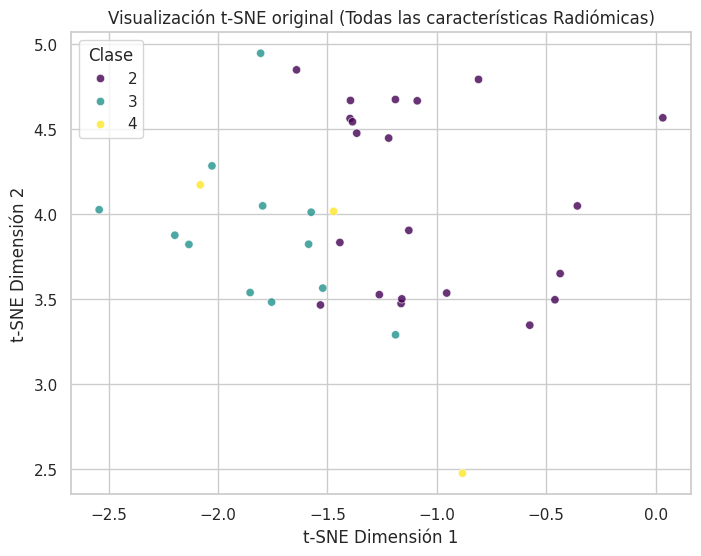

In [ ]:
# Aplicar t-SNE
tsne_all = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne_all = tsne_all.fit_transform(X_scaled)

# Graficar
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne_all[:, 0], y=X_tsne_all[:, 1], hue=y, palette="viridis", alpha=0.8)
plt.title("Visualización t-SNE original (Todas las características Radiómicas)")
plt.xlabel("t-SNE Dimensión 1")
plt.ylabel("t-SNE Dimensión 2")
plt.legend(title="Clase")
plt.show()

# **5: Pipeline de Selección de Características (*Feature Selection*)**
Utilizaremos `SelectKBest` con el método ANOVA (`f_classif`) para evaluar estadísticamente qué características diferencian mejor las clases de las imágenes T1. Elegiremos las 10 mejores de forma puramente académica.

In [ ]:
# Configurar para seleccionar las K mejores características
num_features_to_select = 10
selector = SelectKBest(score_func=f_classif, k=num_features_to_select)

# Ajustar y transformar el espacio de características
X_selected = selector.fit_transform(X_scaled, y)

# Obtener los nombres de las columnas seleccionadas para la explicación médica/clínica
selected_indices = selector.get_support(indices=True)
selected_features_names = X.columns[selected_indices]

print(f"¡Éxito! Reducido de {X.shape[1]} a {X_selected.shape[1]} características.")
print("\nLas características radiómicas más importantes seleccionadas son:")
for i, name in enumerate(selected_features_names, 1):
    print(f"{i}. {name}")

¡Éxito! Reducido de 107 a 10 características.

Las características radiómicas más importantes seleccionadas son:
1. 10Percentile T1
2. Energy T1
3. Range T1
4. Total Energy T1
5. GLDM Large Dependence High Gray Level Emphasis T1
6. GLDM Small Dependence Low Gray Level Emphasis T1
7. GLRLM Low Gray Level Run Emphasis T1
8. GLRLM Short Run Low Gray Level Emphasis T1
9. GLSZM Low Gray Level Zone Emphasis T1
10. GLSZM Small Area Low Gray Level Emphasis T1


# **6: Explicación de Importancia - Gráfico de Puntuaciones (Scores)**
Para la explicación académica, mostramos cuantitativamente por qué se eligieron esas variables.

/tmp/ipykernel_7955/2158287596.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score_F', y='Característica', data=features_scores, palette="rocket")


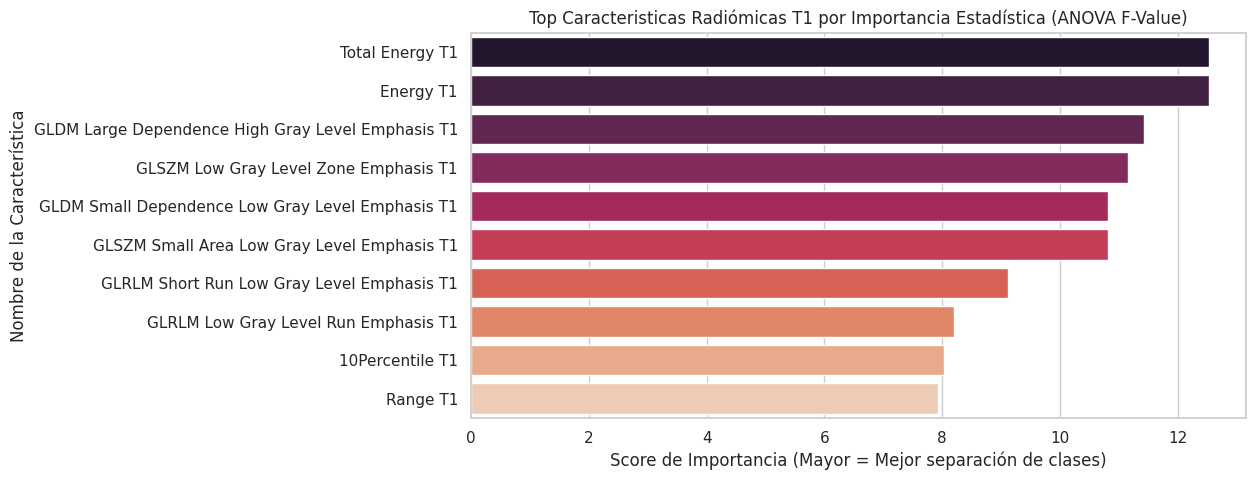

In [ ]:
# Crear un DataFrame con los scores de importancia
features_scores = pd.DataFrame({
    'Característica': X.columns,
    'Score_F': selector.scores_
})

# Ordenar y tomar las mejores
features_scores = features_scores.sort_values(by='Score_F', ascending=False).head(num_features_to_select)

# Graficar la importancia
plt.figure(figsize=(10, 5))
sns.barplot(x='Score_F', y='Característica', data=features_scores, palette="rocket")
plt.title("Top Caracteristicas Radiómicas T1 por Importancia Estadística (ANOVA F-Value)")
plt.xlabel("Score de Importancia (Mayor = Mejor separación de clases)")
plt.ylabel("Nombre de la Característica")
plt.show()

# **7: Evaluación con t-SNE usando solo las características seleccionadas**
El clímax del *pipeline*: Al aplicar t-SNE únicamente sobre las características seleccionadas, deberías observar cómo los grupos (clusters) se definen de mejor manera en el espacio bidimensional, lo que demuestra la efectividad de la selección.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


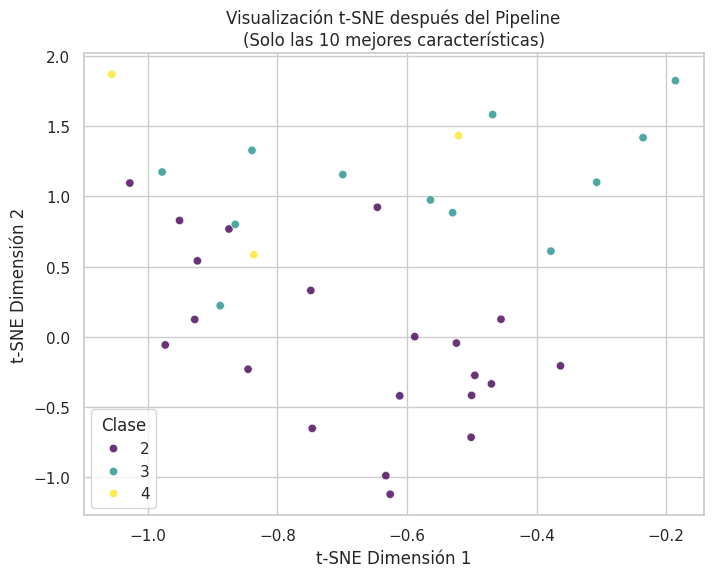

In [ ]:
# Aplicar t-SNE sobre el dataset filtrado
tsne_selected = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne_selected = tsne_selected.fit_transform(X_selected)

# Graficar
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne_selected[:, 0], y=X_tsne_selected[:, 1], hue=y, palette="viridis", alpha=0.8)
plt.title(f"Visualización t-SNE después del Pipeline\n(Solo las {num_features_to_select} mejores características)")
plt.xlabel("t-SNE Dimensión 1")
plt.ylabel("t-SNE Dimensión 2")
plt.legend(title="Clase")
plt.show()

# **8: Clasificación Binaria (LGG vs HGG) y Matriz de Confusión**

Distribución de las nuevas clases biológicas:
Classes
LGG    21
HGG    15
Name: count, dtype: int64


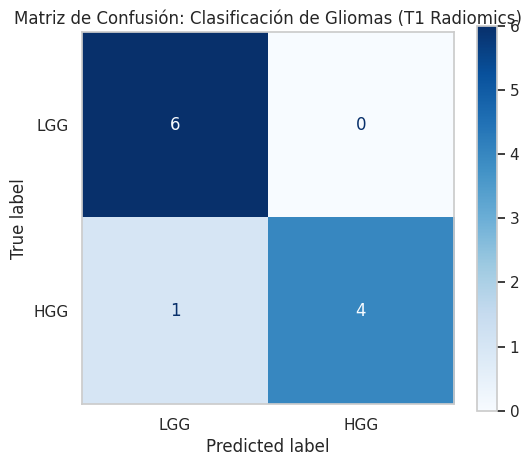


=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

         HGG       1.00      0.80      0.89         5
         LGG       0.86      1.00      0.92         6

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Mapear las clases originales a LGG y HGG según la lógica clínica
# Primero asegurémonos de qué valores tiene 'y' (asumiendo que son enteros 2, 3, 4)
# Creamos un diccionario de mapeo
mapping = {2: 'LGG', 3: 'HGG', 4: 'HGG'}

# Si en tu dataset las clases vienen como texto (ej. "Grade II", "Grade III"),
# ajusta el mapeo reemplazando los números por los strings exactos.
y_binary = y.map(mapping)

print("Distribución de las nuevas clases biológicas:")
print(y_binary.value_counts())

# 2. Dividir el dataset en entrenamiento y prueba (usando las características seleccionadas)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# 3. Entrenar un clasificador académico simple (Regresión Logística)
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train, y_train)

# 4. Realizar predicciones con los datos de prueba
y_pred = classifier.predict(X_test)

# 5. Calcular la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=['LGG', 'HGG'])

# 6. Graficar la Matriz de Confusión de forma elegante
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LGG', 'HGG'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

plt.title("Matriz de Confusión: Clasificación de Gliomas (T1 Radiomics)")
plt.grid(False) # Quitar líneas de cuadrícula para que se vea limpio
plt.show()

# 7. Mostrar reporte de métricas (Precisión, Recall, F1-Score)
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

# **¿Qué representa la matriz de confusión?**

Al presentar la matriz de confusión, estarás demostrando el **rendimiento real del pipeline**:

* **Verdaderos LGG (Arriba-Izquierda):** Pacientes con grado 2 correctamente identificados por las texturas de la resonancia T1.

* **Verdaderos HGG (Abajo-Derecha):** Pacientes con grado 3 y 4 que el algoritmo reconoció exitosamente como tumores de alto grado.

* **Errores (Diagonales secundarias):** Casos donde la radiómica del tumor de grado 2 se asemeja visualmente a uno de grado 3 (o viceversa), lo cual es un desafío clínico real.